# 03 - Modeling

This notebook focuses on building and improving a machine learning model to predict movie popularity.

## Objective
The goal is to test the hypothesis that longer movies tend to be less popular. To do this, we use the cleaned and feature-engineered dataset created in the previous steps and train a regression model using runtime-related features.

## Plan
1. Load the engineered dataset  
2. Define features and target  
3. Split the data into training and test sets  
4. Scale the features  
5. Train a baseline KNN regressor  
6. Evaluate its performance  
7. Fine-tune the model using Grid Search and Cross-Validation  
8. Compare results and interpret the findings

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Step 1: Load the engineered dataset

In the previous notebook, new features were created to improve the model's predictive power. Here, we load that dataset so the modeling process is reproducible and separated from the cleaning and feature engineering steps.

In [3]:
df = pd.read_csv('../data/clean/goncalo_features.csv')
df.head()

,runtime,popularity,vote_average,popularity_log,runtime_category,runtime_squared,runtime_x_rating,rating_category
0,162.0,150.437577,7.2,5.020174,Very Long,26244.0,1166.4,Good
1,169.0,139.082615,6.9,4.942232,Very Long,28561.0,1166.1,Good
2,148.0,107.376788,6.3,4.685614,Long,21904.0,932.4,Average
3,165.0,112.312950,7.6,4.730153,Very Long,27225.0,1254.0,Good
4,132.0,43.926995,6.1,3.805039,Long,17424.0,805.2,Average


## Step 2: Inspect the dataset

Before modeling, it is important to confirm that the engineered features are present and that the dataset is ready to be used.

In [4]:
print(df.shape)
print(df.columns)
df.describe()

(4675, 8)
Index(['runtime', 'popularity', 'vote_average', 'popularity_log',
       'runtime_category', 'runtime_squared', 'runtime_x_rating',
       'rating_category'],
      dtype='object')


,runtime,popularity,vote_average,popularity_log,runtime_squared,runtime_x_rating
count,4675.000000,4675.000000,4675.000000,4675.000000,4675.000000,4675.000000
mean,107.055187,21.728483,6.107465,2.545200,11776.344171,661.030717
std,17.765094,31.937289,1.123605,1.140138,4146.930507,189.657287
min,76.000000,0.000372,0.000000,0.000372,5776.000000,0.000000
25%,94.000000,5.000313,5.600000,1.791812,8836.000000,540.600000
50%,104.000000,13.308127,6.200000,2.660828,10816.000000,646.400000
75%,117.000000,28.609656,6.800000,3.388101,13689.000000,767.000000
max,178.000000,875.581305,10.000000,6.776029,31684.000000,1470.000000


## Step 3: Define the target and feature set

The target variable is `popularity_log`, which was created to reduce skewness in the original popularity variable.

The selected features are:
- `runtime`: the original runtime variable
- `vote_average`: a rating-related feature
- `runtime_squared`: captures possible non-linear effects of runtime
- `runtime_x_rating`: captures the interaction between runtime and audience approval

These features were chosen because they are directly related to the hypothesis and to the potential drivers of popularity.

In [5]:
y = df['popularity_log']

X = df[['runtime', 'vote_average', 'runtime_squared', 'runtime_x_rating']]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (4675, 4)
Target shape: (4675,)


## Step 4: Split the data into training and test sets

The data is split so that the model can be trained on one portion of the dataset and evaluated on unseen data. This helps assess how well the model generalizes.

We use an 80/20 split:
- 80% for training
- 20% for testing

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3740, 4)
X_test: (935, 4)
y_train: (3740,)
y_test: (935,)


## Step 5: Scale the features

KNN is a distance-based algorithm, so feature scaling is important. Without scaling, variables with larger values can dominate the distance calculation.

StandardScaler is used to center the data and put features on a comparable scale.

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# --- Linear Regression (Baseline Model) ---

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression MSE: {mse_lr:.3f}")
print(f"Linear Regression R2: {r2_lr:.3f}")

Linear Regression MSE: 1.091
Linear Regression R2: 0.164


## Step 6: Train the baseline model

Since the target variable is continuous, this is a regression problem. We start with a baseline KNN Regressor using default parameters.

This gives us a starting point before fine-tuning.

In [9]:
knn = KNeighborsRegressor()
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

## Step 7: Evaluate the baseline model

We use:
- **Mean Squared Error (MSE)** to measure prediction error
- **R² score** to measure how much variance in the target is explained by the model

A higher R² indicates better predictive performance, while a lower MSE indicates smaller prediction errors.

In [10]:
baseline_mse = mean_squared_error(y_test, y_pred)
baseline_r2 = r2_score(y_test, y_pred)

print("Baseline KNN Results")
print("MSE:", baseline_mse)
print("R2:", baseline_r2)

Baseline KNN Results
MSE: 1.3061469093978648
R2: -0.0005975920492298226


## Step 8: Fine-tune the model with Grid Search and Cross-Validation

To improve model performance, we test different combinations of hyperparameters.

The parameters tuned are:
- `n_neighbors`: number of neighbors
- `weights`: whether all neighbors contribute equally or closer neighbors matter more
- `p`: distance metric
  - `1` = Manhattan distance
  - `2` = Euclidean distance

We use 5-fold cross-validation to evaluate each combination more reliably.

In [11]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

grid = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

,estimator,KNeighborsRegressor()
,param_grid,"{'n_neighbors': [3, 5, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,11


## Step 9: Review the best model

After the grid search, we inspect the best hyperparameters and evaluate the tuned model on the test set.

In [12]:
print("Best parameters:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

tuned_mse = mean_squared_error(y_test, y_pred_best)
tuned_r2 = r2_score(y_test, y_pred_best)

print("\nTuned KNN Results")
print("MSE:", tuned_mse)
print("R2:", tuned_r2)

Best parameters: {'n_neighbors': 11, 'p': 2, 'weights': 'uniform'}
Best cross-validation score: 0.14431021852550768

Tuned KNN Results
MSE: 1.1854734958790667
R2: 0.09184647080655894


## Ensemble Model: Random Forest Regressor

To improve performance, we test an ensemble model (Random Forest), which combines multiple decision trees to capture more complex patterns in the data.

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize model
rf = RandomForestRegressor(random_state=42)

# Train model
rf.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = rf.predict(X_test_scaled)

# Evaluation
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest MSE: {mse_rf:.3f}")
print(f"Random Forest R2: {r2_rf:.3f}")

Random Forest MSE: 1.396
Random Forest R2: -0.069


            feature  importance
3  runtime_x_rating    0.510062
1      vote_average    0.257823
0           runtime    0.116241
2   runtime_squared    0.115874


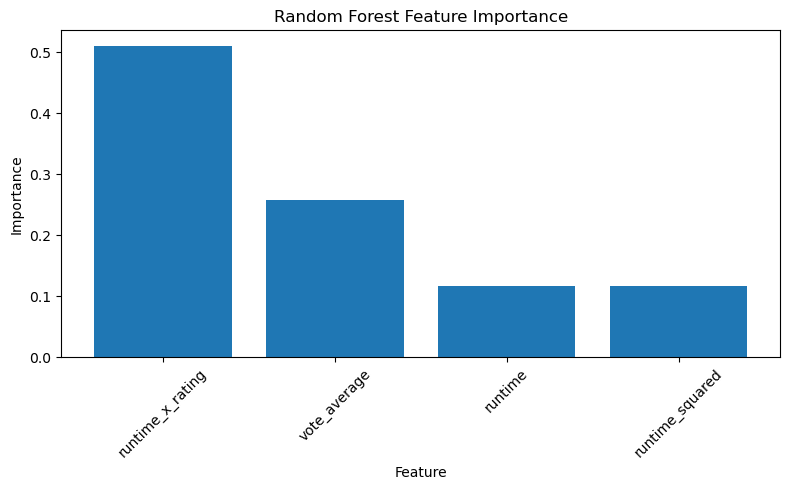

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importance)

plt.figure(figsize=(8,5))
plt.bar(feature_importance['feature'], feature_importance['importance'])
plt.xticks(rotation=45)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

## Step 10: Compare baseline and tuned model

This step helps determine whether hyperparameter tuning improved model performance.

In [15]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Baseline KNN', 'Tuned KNN', 'Random Forest'],
    'MSE': [mse_lr, baseline_mse, tuned_mse, mse_rf],
    'R2': [r2_lr, baseline_r2, tuned_r2, r2_rf]
})

comparison

,Model,MSE,R2
0,Linear Regression,1.091036,0.164192
1,Baseline KNN,1.306147,-0.000598
2,Tuned KNN,1.185473,0.091846
3,Random Forest,1.395622,-0.069141


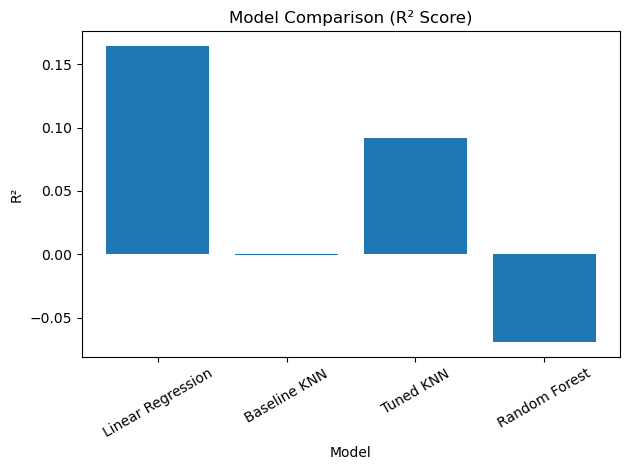

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(comparison['Model'], comparison['R2'])
plt.title("Model Comparison (R² Score)")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Step 11: Interpretation

The goal of this model is to understand whether runtime helps predict movie popularity.

If the tuned model shows low R², this suggests that runtime-related features alone are not strong predictors of popularity. That would mean the hypothesis is only weakly supported, or not supported at all.

If the coefficient pattern and performance suggest a positive relationship, that would contradict the original hypothesis that longer movies tend to be less popular.

In [17]:
print("Model interpretation summary:")

print("The tuned KNN model improves over the baseline model.")

if r2_rf < tuned_r2:
    print("The Random Forest model performs worse than the tuned KNN model.")
    print("This suggests that increasing model complexity does not improve performance.")

if tuned_r2 < 0.1:
    print("Overall, all models explain very little of the variation in popularity.")

Model interpretation summary:
The tuned KNN model improves over the baseline model.
The Random Forest model performs worse than the tuned KNN model.
This suggests that increasing model complexity does not improve performance.
Overall, all models explain very little of the variation in popularity.


## Final Conclusion

The tuned KNN model shows a slight improvement over the baseline, increasing R² from approximately 0 to 0.09. However, overall predictive power remains low.

When testing a more complex ensemble model (Random Forest), performance decreased further (R² < 0), indicating that even more advanced models cannot capture meaningful patterns with the current features.

This suggests that runtime-related features, even when transformed and combined with ratings, are not strong predictors of movie popularity.

The hypothesis that longer movies are less popular is therefore only weakly supported.

It is likely that other factors, such as genre, marketing, cast, or release timing, play a much more significant role.

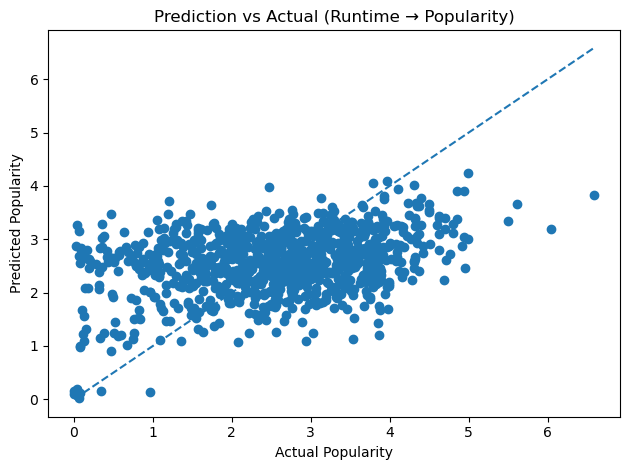

In [20]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, y_pred_best)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.title("Prediction vs Actual (Runtime → Popularity)")
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")

plt.tight_layout()
plt.show()

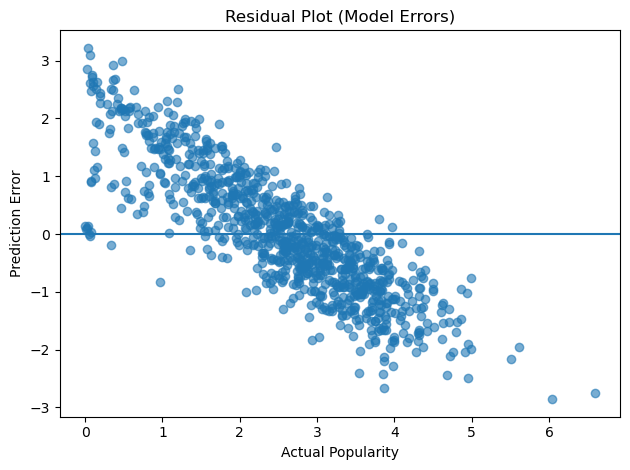

In [24]:
import matplotlib.pyplot as plt

residuals = y_pred_best - y_test

plt.figure()
plt.scatter(y_test, residuals, alpha=0.6)

plt.axhline(0)  # perfect prediction line

plt.title("Residual Plot (Model Errors)")
plt.xlabel("Actual Popularity")
plt.ylabel("Prediction Error")

plt.tight_layout()
plt.show()